# RUTOR GLACIER 1D-CNN CLASSIFICATION
# Earth Observation Advanced - Politecnico di Milano

1D Convolutional Neural Network for 5-class glacier land cover classification.
Uses spectral signatures (10 bands) from Landsat composites.

**Classes:** Clean Ice, Debris Ice, Water, Vegetation, Rock

**Comparison:** CNN vs MLP (scikit-learn) vs Random Forest

In [1]:
!pip install rasterio -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_curve, auc, roc_auc_score, f1_score, precision_score, recall_score
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.19.0
GPU available: True


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Data Loading

In [4]:
# Class and feature definitions (same as MLP notebook)
class_names = {0: 'Clean Ice', 1: 'Debris Ice', 2: 'Water', 3: 'Vegetation', 4: 'Rock'}
feature_names = ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'Thermal', 'NDSI', 'NDVI', 'NDWI']
n_classes = len(class_names)
n_features = len(feature_names)

In [5]:
training_file = "/content/drive/My Drive/EarthObservation/Training_Set_75_Percent.csv"
testing_file  = "/content/drive/My Drive/EarthObservation/Testing_Set_25_Percent.csv"

print("Loading training and testing data...")
train_data = pd.read_csv(training_file).dropna()
test_data  = pd.read_csv(testing_file).dropna()

X_train = train_data[feature_names].values
y_train = train_data['class'].values
X_test  = test_data[feature_names].values
y_test  = test_data['class'].values

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")
print(f"Features: {n_features} | Classes: {n_classes}")

Loading training and testing data...
Training samples: 858
Testing samples:  320
Features: 10 | Classes: 5


# 2. Preprocessing

In [6]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Reshape for 1D-CNN: (samples, bands, 1 channel)
X_train_cnn = X_train_scaled.reshape(-1, n_features, 1)
X_test_cnn  = X_test_scaled.reshape(-1, n_features, 1)

# One-hot encode labels for CNN
y_train_onehot = keras.utils.to_categorical(y_train, n_classes)
y_test_onehot  = keras.utils.to_categorical(y_test, n_classes)

print(f"CNN input shape:  {X_train_cnn.shape}")
print(f"CNN output shape: {y_train_onehot.shape}")

CNN input shape:  (858, 10, 1)
CNN output shape: (858, 5)


# 3. CNN Model Definition & Training

In [ ]:
def build_cnn(input_shape, n_classes):
    """1D-CNN for spectral classification."""
    model = keras.Sequential([
        # Block 1
        layers.Conv1D(64, kernel_size=3, padding='same', activation='relu',
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv1D(64, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv1D(128, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.25),

        # Classifier head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


cnn_model = build_cnn(input_shape=(n_features, 1), n_classes=n_classes)
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 10, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 5, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 5, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,877 (280.77 KB)

 Trainable params: 71,365 (278.77 KB)

 Non-trainable params: 512 (2.00 KB)

In [8]:
# Callbacks
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6
)

# Train
history = cnn_model.fit(
    X_train_cnn, y_train_onehot,
    validation_data=(X_test_cnn, y_test_onehot),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("Finished training")

Epoch 1/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 166ms/step - accuracy: 0.7167 - loss: 0.8194 - val_accuracy: 0.7000 - val_loss: 1.3629 - learning_rate: 0.0010
Epoch 2/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9702 - loss: 0.1003 - val_accuracy: 0.7094 - val_loss: 1.2100 - learning_rate: 0.0010
Epoch 3/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9688 - loss: 0.0850 - val_accuracy: 0.8062 - val_loss: 1.0184 - learning_rate: 0.0010
Epoch 4/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9816 - loss: 0.0549 - val_accuracy: 0.8281 - val_loss: 0.8645 - learning_rate: 0.0010
Epoch 5/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9749 - loss: 0.0824 - val_accuracy: 0.8406 - val_loss: 0.7147 - learning_rate: 0.0010
Epoch 6/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9792 - loss: 0.0794 - val_accuracy: 0.8813 - val_loss: 0.5706 - learning_rate: 0.0010
Epoch 7/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9873 - loss: 0.0347 - val_

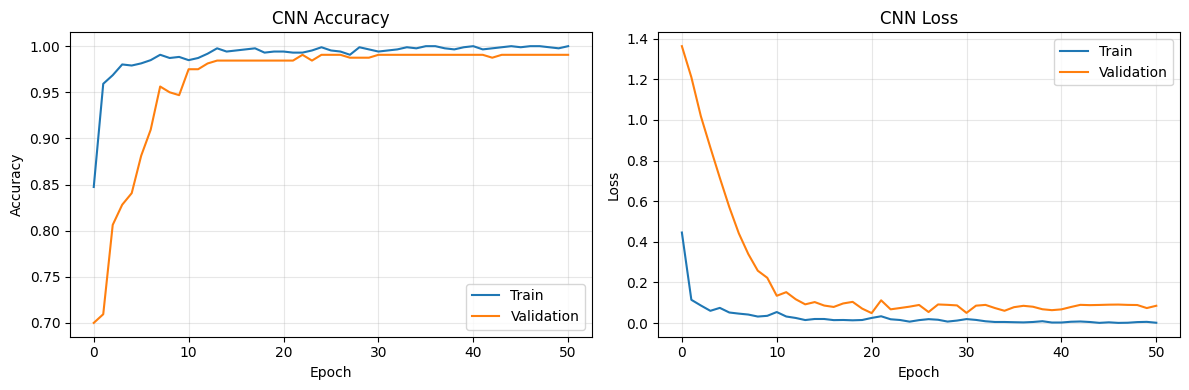

In [9]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('CNN Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('CNN Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Train MLP & RF baselines (for comparison)

In [10]:
# MLP - Triple Layer (best from MLP notebook)
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu', solver='adam',
    alpha=0.001, learning_rate_init=0.001,
    max_iter=1000, random_state=42, early_stopping=True
)
mlp_model.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_model.predict(X_test_scaled)
mlp_train_acc = accuracy_score(y_train, mlp_model.predict(X_train_scaled))
mlp_test_acc  = accuracy_score(y_test, y_pred_mlp)
print(f"MLP  - Train: {mlp_train_acc:.3f} | Test: {mlp_test_acc:.3f}")

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train))
rf_test_acc  = accuracy_score(y_test, y_pred_rf)
print(f"RF   - Train: {rf_train_acc:.3f} | Test: {rf_test_acc:.3f}")

MLP  - Train: 0.993 | Test: 0.978
RF   - Train: 1.000 | Test: 0.991


# 5. CNN Metrics

In [11]:
# CNN predictions
y_pred_cnn_proba = cnn_model.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_cnn_proba, axis=1)

cnn_train_proba = cnn_model.predict(X_train_cnn)
y_pred_cnn_train = np.argmax(cnn_train_proba, axis=1)
cnn_train_acc = accuracy_score(y_train, y_pred_cnn_train)
cnn_test_acc  = accuracy_score(y_test, y_pred_cnn)

print(f"CNN  - Train: {cnn_train_acc:.3f} | Test: {cnn_test_acc:.3f} | Overfitting: {cnn_train_acc - cnn_test_acc:.3f}")

class_names_list = [class_names[i] for i in range(n_classes)]

print("\n=== CNN Classification Report ===")
print(classification_report(y_test, y_pred_cnn, target_names=class_names_list))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_cnn))

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step  
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
CNN  - Train: 0.999 | Test: 0.984 | Overfitting: 0.014

=== CNN Classification Report ===
              precision    recall  f1-score   support

   Clean Ice       1.00      0.92      0.96        53
  Debris Ice       0.93      0.96      0.94        26
       Water       1.00      1.00      1.00        18
  Vegetation       1.00      1.00      1.00        47
        Rock       0.98      1.00      0.99       176

    accuracy                           0.98       320
   macro avg       0.98      0.98      0.98       320
weighted avg       0.98      0.98      0.98       320

Confusion Matrix:
[[ 49   2   0   0   2]
 [  0  25   0   0   1]
 [  0   0  18   0   0]
 [  0   0   0  47   0]
 [  0   0   0   0 176]]


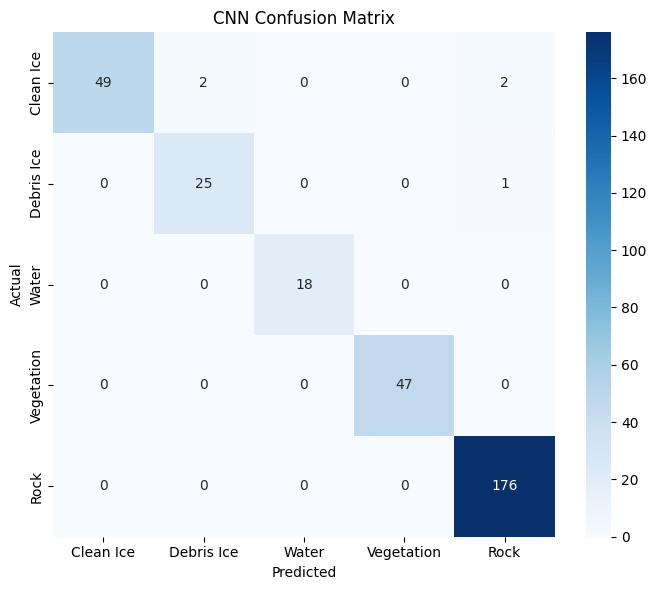

In [12]:
# Confusion matrix heatmap for CNN
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_list, yticklabels=class_names_list)
plt.title('CNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

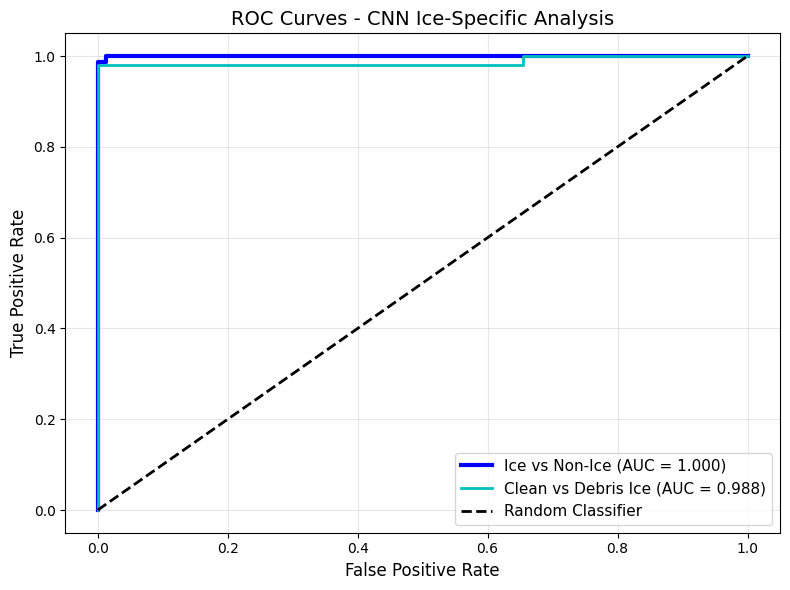

Ice detection AUC: 1.000


In [13]:
# ROC curves for CNN (ice-specific)
ice_classes = [0, 1]
y_true_ice = np.isin(y_test, ice_classes).astype(int)
y_pred_ice_proba = y_pred_cnn_proba[:, 0] + y_pred_cnn_proba[:, 1]

fpr_ice, tpr_ice, _ = roc_curve(y_true_ice, y_pred_ice_proba)
roc_auc_ice = auc(fpr_ice, tpr_ice)

# Clean vs Debris within ice pixels
ice_mask = np.isin(y_test, ice_classes)
fpr_clean, tpr_clean, roc_auc_clean = None, None, None
if np.sum(ice_mask) > 0 and len(np.unique(y_test[ice_mask])) > 1:
    fpr_clean, tpr_clean, _ = roc_curve(
        (y_test[ice_mask] == 0).astype(int),
        y_pred_cnn_proba[ice_mask, 0]
    )
    roc_auc_clean = auc(fpr_clean, tpr_clean)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ice, tpr_ice, 'b-', lw=3, label=f'Ice vs Non-Ice (AUC = {roc_auc_ice:.3f})')
if fpr_clean is not None:
    plt.plot(fpr_clean, tpr_clean, 'c-', lw=2, label=f'Clean vs Debris Ice (AUC = {roc_auc_clean:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - CNN Ice-Specific Analysis', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Ice detection AUC: {roc_auc_ice:.3f}")

# 6. Temporal Analysis - Ice Cover Evolution

In [ ]:
def load_gee_composite(filepath):
    """Load a multi-band GeoTIFF composite exported from GEE."""
    with rasterio.open(filepath) as src:
        data = src.read()            # (bands, H, W)
        data = np.moveaxis(data, 0, -1)  # -> (H, W, bands)
        return data, src.transform, src.crs, src.profile


def classify_composite_cnn(model, scaler, data, n_features,
                           confidence_threshold=0.6, ndsi_threshold=0.2):
    """Apply trained CNN to a full raster composite.

    Two-stage filtering to reduce ice overestimation:
      1. Confidence threshold: low-confidence pixels default to Rock.
      2. NDSI physical constraint: pixels classified as Clean Ice (0)
         but with NDSI below the threshold are reclassified to Rock,
         since real clean ice/snow always has high NDSI.

    Band order: Blue, Green, Red, NIR, SWIR1, SWIR2, Thermal, NDSI, NDVI, NDWI
    -> NDSI is at index 7.
    """
    h, w, bands = data.shape
    if bands != n_features:
        print(f"  Expected {n_features} bands, got {bands}. Skipping.")
        return None

    flat = data.reshape(-1, n_features)

    # Mask out nodata pixels (all zeros or NaN)
    valid = ~(np.isnan(flat).any(axis=1) | (flat == 0).all(axis=1))

    classification = np.full(flat.shape[0], -1, dtype=np.int8)
    if valid.sum() > 0:
        scaled = scaler.transform(flat[valid])
        cnn_input = scaled.reshape(-1, n_features, 1)
        proba = model.predict(cnn_input, batch_size=1024, verbose=0)

        preds = np.argmax(proba, axis=1)
        max_proba = np.max(proba,axis=1)

        # Stage 1 — Low-confidence pixels -> default to Rock (4)
        preds[max_proba < confidence_threshold] = 4

        # Stage 2 — NDSI physical constraint on Clean Ice
        # Real clean ice / snow has high NDSI; if NDSI is low it's
        # likely rock or debris misclassified as ice
        ndsi_vals = flat[valid, 7]   # NDSI band (index 7)
        clean_ice_mask = (preds == 0) & (ndsi_vals < ndsi_threshold)
        preds[clean_ice_mask] = 4    # reclassify to Rock

        classification[valid] = preds

    return classification.reshape(h, w)


def save_classification_geotiff(classification, profile, filepath):
    """Save a classification map as single-band GeoTIFF."""
    out_profile = profile.copy()
    out_profile.update(dtype='int8', count=1, nodata=-1)
    with rasterio.open(filepath, 'w', **out_profile) as dst:
        dst.write(classification.astype(np.int8), 1)
    print(f"  Saved: {filepath}")

In [15]:
# Load RF temporal data from GEE exports
rf_evolution_file = "/content/drive/My Drive/EarthObservation/Rutor_Ice_Evolution_1984_2024.csv"
rf_evo = pd.read_csv(rf_evolution_file)

rf_temporal = {'years': [], 'total_ice_km2': [], 'clean_ice_km2': [], 'debris_ice_km2': []}
for _, row in rf_evo.iterrows():
    start, end = map(int, row['period'].split('-'))
    rf_temporal['years'].append((start + end) // 2)
    rf_temporal['total_ice_km2'].append(row['total_ice_km2'])
    rf_temporal['clean_ice_km2'].append(row['clean_ice_km2'])
    rf_temporal['debris_ice_km2'].append(row['debris_ice_km2'])

print(f"RF evolution data loaded: {len(rf_temporal['years'])} periods")

RF evolution data loaded: 8 periods


In [16]:
# Apply CNN to historical composites and compute ice area
time_periods = [
    {'name': '1984-1988', 'mid_year': 1986},
    {'name': '1989-1993', 'mid_year': 1991},
    {'name': '1994-1998', 'mid_year': 1996},
    {'name': '1999-2003', 'mid_year': 2001},
    {'name': '2004-2008', 'mid_year': 2006},
    {'name': '2009-2013', 'mid_year': 2011},
    {'name': '2014-2018', 'mid_year': 2016},
    {'name': '2019-2024', 'mid_year': 2021},
]

pixel_area_km2 = 0.0009   # 30 m x 30 m

cnn_temporal = {'years': [], 'total_ice_km2': [], 'clean_ice_km2': [], 'debris_ice_km2': []}

print("=== APPLYING CNN TO HISTORICAL COMPOSITES ===")
for period in time_periods:
    fname = f"composite_{period['name'].replace('-', '_')}.tif"
    fpath = f"/content/drive/My Drive/MLP_Glacier_Composites/{fname}"

    try:
        data, transform, crs, profile = load_gee_composite(fpath)
        print(f"\n{period['name']} - shape {data.shape}")

        cmap = classify_composite_cnn(cnn_model, scaler, data, n_features)
        if cmap is None:
            continue

        clean_px  = np.sum(cmap == 0)
        debris_px = np.sum(cmap == 1)
        clean_km2  = clean_px  * pixel_area_km2
        debris_km2 = debris_px * pixel_area_km2
        total_km2  = clean_km2 + debris_km2

        cnn_temporal['years'].append(period['mid_year'])
        cnn_temporal['total_ice_km2'].append(total_km2)
        cnn_temporal['clean_ice_km2'].append(clean_km2)
        cnn_temporal['debris_ice_km2'].append(debris_km2)

        print(f"  Total ice: {total_km2:.2f} km2  (clean: {clean_km2:.2f}, debris: {debris_km2:.2f})")

        # Save classification
        save_path = f"/content/drive/My Drive/EarthObservation/CNN_Classification_{period['name'].replace('-','_')}.tif"
        save_classification_geotiff(cmap, profile, save_path)

    except Exception as e:
        print(f"  {period['name']}: skipped ({e})")

print(f"\nProcessed {len(cnn_temporal['years'])} / {len(time_periods)} periods")

=== APPLYING CNN TO HISTORICAL COMPOSITES ===

1984-1988 - shape (477, 651, 10)
  Total ice: 57.86 km2  (clean: 30.67, debris: 27.19)
  Saved: /content/drive/My Drive/EarthObservation/CNN_Classification_1984_1988.tif

1989-1993 - shape (477, 651, 10)
  Total ice: 54.38 km2  (clean: 25.82, debris: 28.56)
  Saved: /content/drive/My Drive/EarthObservation/CNN_Classification_1989_1993.tif

1994-1998 - shape (477, 651, 10)
  Total ice: 52.79 km2  (clean: 28.44, debris: 24.35)
  Saved: /content/drive/My Drive/EarthObservation/CNN_Classification_1994_1998.tif

1999-2003 - shape (477, 651, 10)
  Total ice: 42.53 km2  (clean: 23.25, debris: 19.29)
  Saved: /content/drive/My Drive/EarthObservation/CNN_Classification_1999_2003.tif

2004-2008 - shape (477, 651, 10)
  Total ice: 43.43 km2  (clean: 19.37, debris: 24.07)
  Saved: /content/drive/My Drive/EarthObservation/CNN_Classification_2004_2008.tif

2009-2013 - shape (477, 651, 10)
  Total ice: 43.94 km2  (clean: 17.01, debris: 26.92)
  Saved: /c

# 7. Ice Cover Evolution Plot

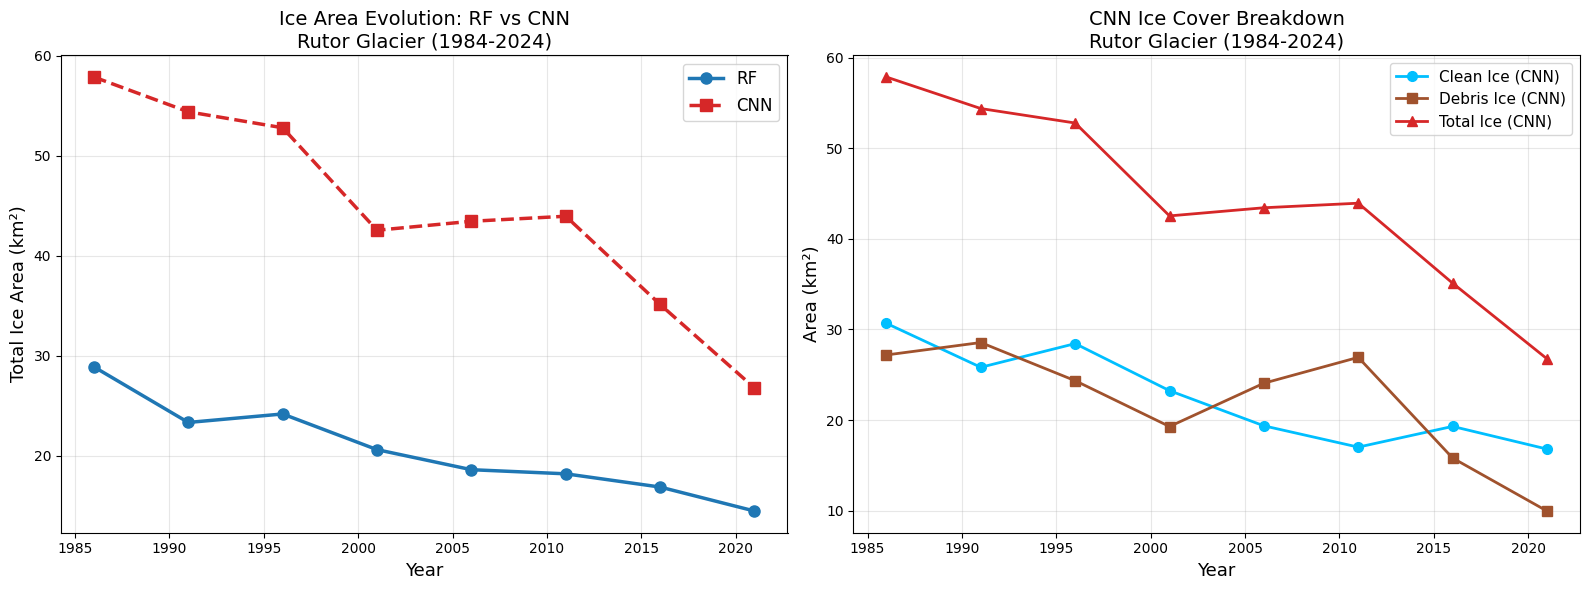


=== CNN ICE AREA EVOLUTION ===
  Year  Clean (km2)  Debris (km2)  Total (km2)
------------------------------------------------
  1986        30.67         27.19        57.86
  1991        25.82         28.56        54.38
  1996        28.44         24.35        52.79
  2001        23.25         19.29        42.53
  2006        19.37         24.07        43.43
  2011        17.01         26.92        43.94
  2016        19.30         15.81        35.11
  2021        16.80          9.96        26.76

Total ice loss (CNN): 53.7%


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Total ice comparison RF vs CNN ---
ax = axes[0]
ax.plot(rf_temporal['years'], rf_temporal['total_ice_km2'],
        'o-', lw=2.5, ms=8, color='#1f77b4', label='RF')
if cnn_temporal['years']:
    ax.plot(cnn_temporal['years'], cnn_temporal['total_ice_km2'],
            's--', lw=2.5, ms=8, color='#d62728', label='CNN')
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Total Ice Area (km\u00b2)', fontsize=13)
ax.set_title('Ice Area Evolution: RF vs CNN\nRutor Glacier (1984-2024)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# --- Right: Clean vs Debris ice (CNN) ---
ax = axes[1]
if cnn_temporal['years']:
    ax.plot(cnn_temporal['years'], cnn_temporal['clean_ice_km2'],
            'o-', lw=2, ms=7, color='deepskyblue', label='Clean Ice (CNN)')
    ax.plot(cnn_temporal['years'], cnn_temporal['debris_ice_km2'],
            's-', lw=2, ms=7, color='sienna', label='Debris Ice (CNN)')
    ax.plot(cnn_temporal['years'], cnn_temporal['total_ice_km2'],
            '^-', lw=2, ms=7, color='#d62728', label='Total Ice (CNN)')
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Area (km\u00b2)', fontsize=13)
ax.set_title('CNN Ice Cover Breakdown\nRutor Glacier (1984-2024)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary table
if cnn_temporal['years']:
    print("\n=== CNN ICE AREA EVOLUTION ===")
    print(f"{'Year':>6} {'Clean (km2)':>12} {'Debris (km2)':>13} {'Total (km2)':>12}")
    print('-' * 48)
    for i, yr in enumerate(cnn_temporal['years']):
        print(f"{yr:6d} {cnn_temporal['clean_ice_km2'][i]:12.2f} "
              f"{cnn_temporal['debris_ice_km2'][i]:13.2f} {cnn_temporal['total_ice_km2'][i]:12.2f}")

    loss_pct = (1 - cnn_temporal['total_ice_km2'][-1] / cnn_temporal['total_ice_km2'][0]) * 100
    print(f"\nTotal ice loss (CNN): {loss_pct:.1f}%")

# 8. Model Comparison: CNN vs MLP vs RF

In [18]:
# ---- Accuracy summary table ----
models_summary = {
    'CNN':            {'train': cnn_train_acc,  'test': cnn_test_acc,  'preds': y_pred_cnn},
    'MLP (128-64-32)':{'train': mlp_train_acc,  'test': mlp_test_acc,  'preds': y_pred_mlp},
    'Random Forest':  {'train': rf_train_acc,   'test': rf_test_acc,   'preds': y_pred_rf},
}

print("=== MODEL COMPARISON ===")
print(f"{'Model':<20} {'Train Acc':>10} {'Test Acc':>10} {'Overfitting':>12} {'F1 (macro)':>11}")
print('-' * 65)
for name, m in models_summary.items():
    overfit = m['train'] - m['test']
    f1 = f1_score(y_test, m['preds'], average='macro')
    print(f"{name:<20} {m['train']:10.3f} {m['test']:10.3f} {overfit:12.3f} {f1:11.3f}")

=== MODEL COMPARISON ===
Model                 Train Acc   Test Acc  Overfitting  F1 (macro)
-----------------------------------------------------------------
CNN                       0.999      0.984        0.014       0.979
MLP (128-64-32)           0.993      0.978        0.015       0.967
Random Forest             1.000      0.991        0.009       0.991


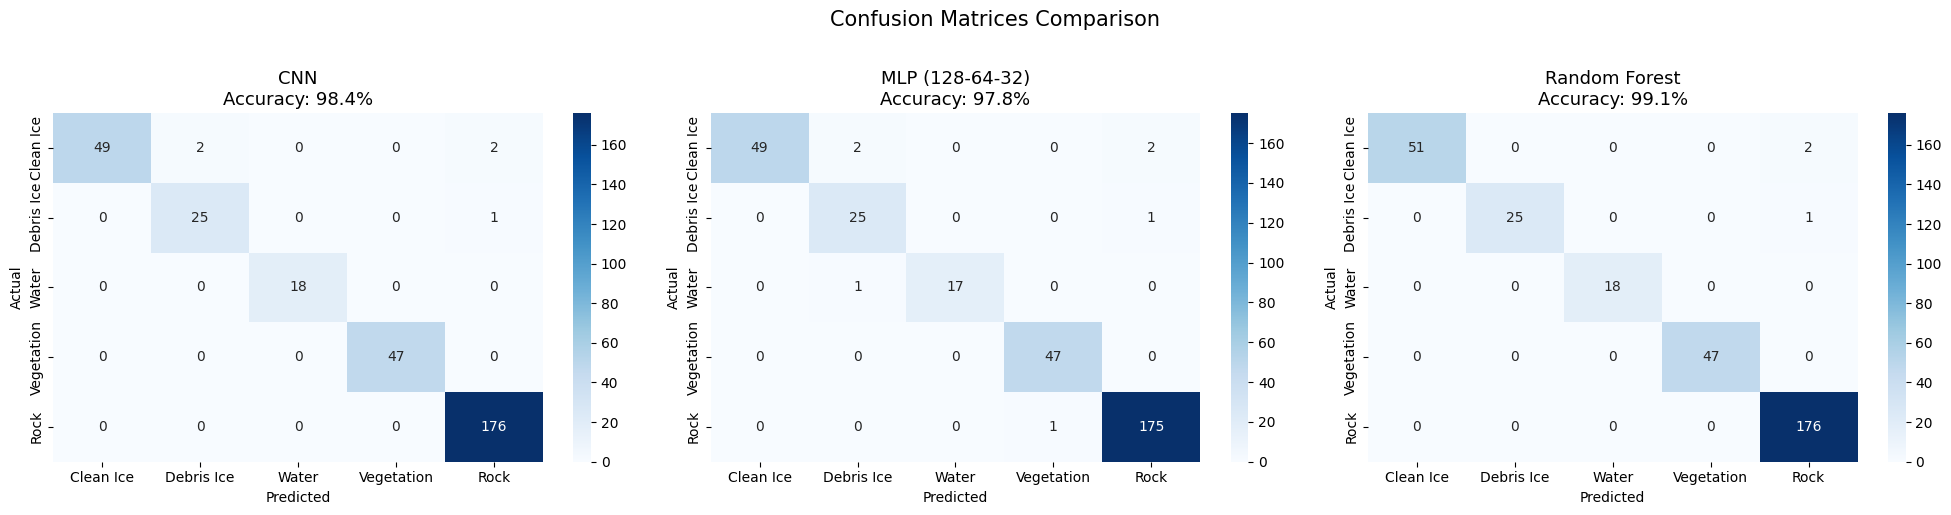

In [19]:
# ---- Side-by-side confusion matrices ----
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (name, m) in zip(axes, models_summary.items()):
    cm = confusion_matrix(y_test, m['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names_list, yticklabels=class_names_list)
    ax.set_title(f'{name}\nAccuracy: {m["test"]:.1%}', fontsize=13)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices Comparison', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

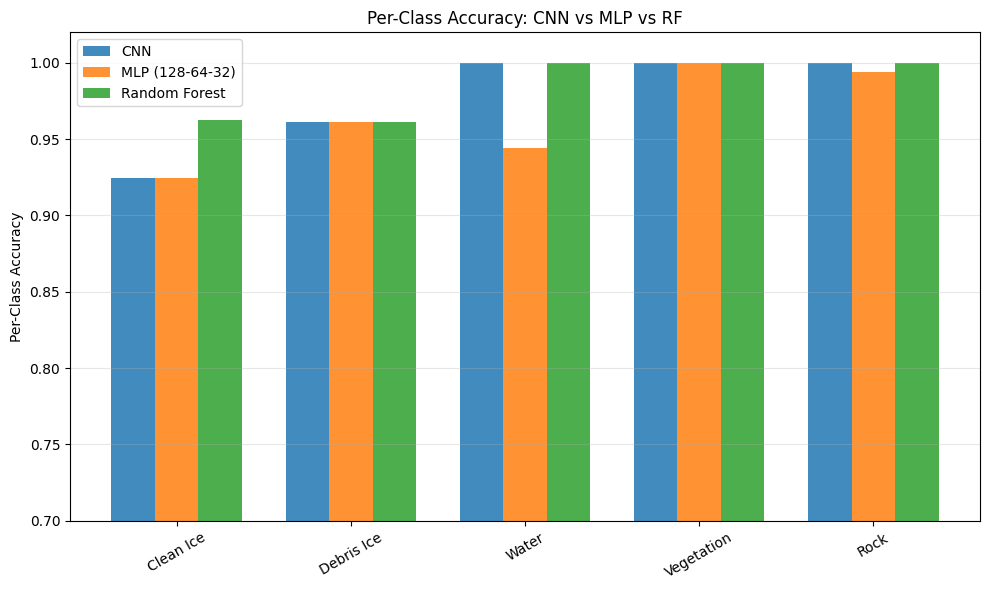

In [20]:
# ---- Per-class accuracy comparison ----
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(n_classes)
width = 0.25

for offset, (name, m) in enumerate(models_summary.items()):
    per_class = []
    for c in range(n_classes):
        mask = y_test == c
        per_class.append(accuracy_score(y_test[mask], m['preds'][mask]) if mask.sum() > 0 else 0)
    ax.bar(x + (offset - 1) * width, per_class, width, label=name, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(class_names_list, rotation=30)
ax.set_ylabel('Per-Class Accuracy')
ax.set_title('Per-Class Accuracy: CNN vs MLP vs RF')
ax.legend()
ax.set_ylim(0.7, 1.02)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

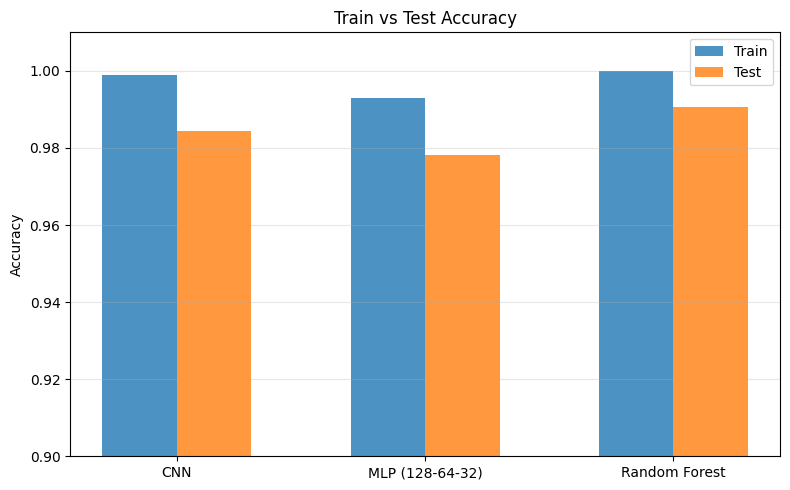

In [21]:
# ---- Accuracy bar chart ----
fig, ax = plt.subplots(figsize=(8, 5))

names = list(models_summary.keys())
train_accs = [models_summary[n]['train'] for n in names]
test_accs  = [models_summary[n]['test']  for n in names]

x = np.arange(len(names))
w = 0.3
ax.bar(x - w/2, train_accs, w, label='Train', alpha=0.8)
ax.bar(x + w/2, test_accs,  w, label='Test',  alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy')
ax.set_ylim(0.9, 1.01)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

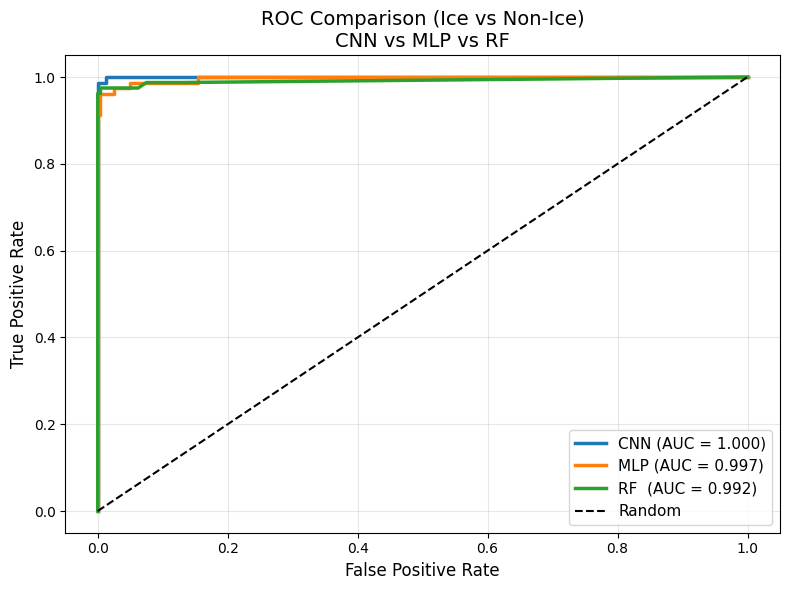

In [22]:
# ---- ROC comparison (ice vs non-ice) ----
plt.figure(figsize=(8, 6))

# CNN
cnn_ice_proba = y_pred_cnn_proba[:, 0] + y_pred_cnn_proba[:, 1]
fpr_cnn, tpr_cnn, _ = roc_curve(y_true_ice, cnn_ice_proba)
auc_cnn = auc(fpr_cnn, tpr_cnn)
plt.plot(fpr_cnn, tpr_cnn, lw=2.5, label=f'CNN (AUC = {auc_cnn:.3f})')

# MLP
mlp_proba = mlp_model.predict_proba(X_test_scaled)
mlp_ice_proba = mlp_proba[:, 0] + mlp_proba[:, 1]
fpr_mlp, tpr_mlp, _ = roc_curve(y_true_ice, mlp_ice_proba)
auc_mlp = auc(fpr_mlp, tpr_mlp)
plt.plot(fpr_mlp, tpr_mlp, lw=2.5, label=f'MLP (AUC = {auc_mlp:.3f})')

# RF
rf_proba = rf_model.predict_proba(X_test)
rf_ice_proba = rf_proba[:, 0] + rf_proba[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_true_ice, rf_ice_proba)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, lw=2.5, label=f'RF  (AUC = {auc_rf:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Comparison (Ice vs Non-Ice)\nCNN vs MLP vs RF', fontsize=14)
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# ---- Detailed per-model classification reports ----
for name, m in models_summary.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, m['preds'], target_names=class_names_list))


  CNN
              precision    recall  f1-score   support

   Clean Ice       1.00      0.92      0.96        53
  Debris Ice       0.93      0.96      0.94        26
       Water       1.00      1.00      1.00        18
  Vegetation       1.00      1.00      1.00        47
        Rock       0.98      1.00      0.99       176

    accuracy                           0.98       320
   macro avg       0.98      0.98      0.98       320
weighted avg       0.98      0.98      0.98       320


  MLP (128-64-32)
              precision    recall  f1-score   support

   Clean Ice       1.00      0.92      0.96        53
  Debris Ice       0.89      0.96      0.93        26
       Water       1.00      0.94      0.97        18
  Vegetation       0.98      1.00      0.99        47
        Rock       0.98      0.99      0.99       176

    accuracy                           0.98       320
   macro avg       0.97      0.96      0.97       320
weighted avg       0.98      0.98      0.98       3

In [24]:
# ---- Ice area temporal comparison table (RF vs CNN) ----
if cnn_temporal['years']:
    print("\n=== TEMPORAL ICE AREA: RF vs CNN ===")
    print(f"{'Year':>6} {'RF (km2)':>10} {'CNN (km2)':>10} {'Diff (km2)':>11} {'Diff (%)':>9}")
    print('-' * 50)
    for i, yr in enumerate(rf_temporal['years']):
        if i < len(cnn_temporal['years']):
            rf_val  = rf_temporal['total_ice_km2'][i]
            cnn_val = cnn_temporal['total_ice_km2'][i]
            diff    = cnn_val - rf_val
            pct     = (diff / rf_val * 100) if rf_val > 0 else 0
            print(f"{yr:6d} {rf_val:10.2f} {cnn_val:10.2f} {diff:11.2f} {pct:8.1f}%")

    # Correlation
    n = min(len(rf_temporal['total_ice_km2']), len(cnn_temporal['total_ice_km2']))
    if n >= 3:
        corr = np.corrcoef(rf_temporal['total_ice_km2'][:n], cnn_temporal['total_ice_km2'][:n])[0, 1]
        print(f"\nCorrelation (RF vs CNN): {corr:.3f}")

    rf_loss  = (1 - rf_temporal['total_ice_km2'][-1] / rf_temporal['total_ice_km2'][0]) * 100
    cnn_loss = (1 - cnn_temporal['total_ice_km2'][-1] / cnn_temporal['total_ice_km2'][0]) * 100
    print(f"\nOverall ice loss  RF: {rf_loss:.1f}%  |  CNN: {cnn_loss:.1f}%")
else:
    print("No CNN temporal data available (composites not found on Drive).")


=== TEMPORAL ICE AREA: RF vs CNN ===
  Year   RF (km2)  CNN (km2)  Diff (km2)  Diff (%)
--------------------------------------------------
  1986      28.87      57.86       28.99    100.4%
  1991      23.31      54.38       31.07    133.3%
  1996      24.16      52.79       28.63    118.5%
  2001      20.59      42.53       21.94    106.6%
  2006      18.58      43.43       24.85    133.7%
  2011      18.17      43.94       25.76    141.8%
  2016      16.85      35.11       18.26    108.4%
  2021      14.45      26.76       12.31     85.2%

Correlation (RF vs CNN): 0.935

Overall ice loss  RF: 49.9%  |  CNN: 53.7%


In [25]:
print("\n=== FINAL SUMMARY ===")
best_name = max(models_summary, key=lambda n: models_summary[n]['test'])
print(f"Best overall model: {best_name} ({models_summary[best_name]['test']:.1%} test accuracy)")
print(f"CNN test accuracy: {cnn_test_acc:.1%}")
print(f"MLP test accuracy: {mlp_test_acc:.1%}")
print(f"RF  test accuracy: {rf_test_acc:.1%}")


=== FINAL SUMMARY ===
Best overall model: Random Forest (99.1% test accuracy)
CNN test accuracy: 98.4%
MLP test accuracy: 97.8%
RF  test accuracy: 99.1%
